# Entraînement MobileNetV2 (CPU Optimisé)

| Paramètre | Valeur | Raison |
|---|---|---|
| Architecture | MobileNetV2 | 3.4M params vs 19M pour EfficientNet-B4 |
| Input size | 128×128 | Cohérent avec Notebook 1 |
| Batch size | 16 | Meilleure convergence sur petit dataset |
| Phase 1 epochs | 20 | Tête seulement, base gelée |
| Phase 2 epochs | 30 | Fine-tuning 30 dernières couches |
| LR Phase 1 | 5e-4 | Plus stable que 1e-3 |
| LR Phase 2 | 1e-5 | Très faible pour ne pas détruire les poids |
| Temps estimé CPU | ~45-60 min total | |

---

## Imports & Configuration

In [2]:
import os, random, warnings, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

warnings.filterwarnings('ignore')

SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)

# ── Chemins ───────────────────────────────────────────────
PROCESSED_DIR = r'..\data\processed'
MODELS_DIR    = r'..\models'
RESULTS_DIR   = r'..\results'
os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

# ── Lire config depuis Notebook 1 ─────────────────────────
with open(os.path.join(PROCESSED_DIR, 'config.json')) as f:
    cfg = json.load(f)
IMG_SIZE = cfg['IMG_SIZE']
print(f'IMG_SIZE chargé depuis config : {IMG_SIZE}')

# ── Hyperparamètres ───────────────────────────────────────
BATCH_SIZE  = 16
EPOCHS_HEAD = 20
EPOCHS_FINE = 30
LR_HEAD     = 5e-4
LR_FINE     = 1e-5
BEST_MODEL  = os.path.join(MODELS_DIR, 'deepshield_best.keras')

print(f'TensorFlow : {tf.__version__}')
print(f'Batch size : {BATCH_SIZE} | Epochs P1: {EPOCHS_HEAD} | Epochs P2: {EPOCHS_FINE}')
print('Config OK')

Exception ignored in PyObject_HasAttr(); consider using PyObject_HasAttrWithError(), PyObject_GetOptionalAttr() or PyObject_GetAttr():
Traceback (most recent call last):
  File "<frozen importlib._bootstrap>", line 488, in _call_with_frames_removed
AttributeError: partially initialized module 'pandas' from 'c:\Users\nasri\OneDrive\Desktop\Projects\DeepShield Detect\venv\Lib\site-packages\pandas\__init__.py' has no attribute '_pandas_datetime_CAPI' (most likely due to a circular import)
Exception ignored in PyObject_HasAttr(); consider using PyObject_HasAttrWithError(), PyObject_GetOptionalAttr() or PyObject_GetAttr():
Traceback (most recent call last):
  File "<frozen importlib._bootstrap>", line 488, in _call_with_frames_removed
AttributeError: partially initialized module 'pandas' from 'c:\Users\nasri\OneDrive\Desktop\Projects\DeepShield Detect\venv\Lib\site-packages\pandas\__init__.py' has no attribute '_pandas_parser_CAPI' (most likely due to a circular import)


IMG_SIZE chargé depuis config : 128
TensorFlow : 2.21.0
Batch size : 16 | Epochs P1: 20 | Epochs P2: 30
Config OK


---
##  Chargement des Données

In [3]:
X_train = np.load(os.path.join(PROCESSED_DIR, 'X_train.npy'))
X_val   = np.load(os.path.join(PROCESSED_DIR, 'X_val.npy'))
X_test  = np.load(os.path.join(PROCESSED_DIR, 'X_test.npy'))
y_train = np.load(os.path.join(PROCESSED_DIR, 'y_train.npy'))
y_val   = np.load(os.path.join(PROCESSED_DIR, 'y_val.npy'))
y_test  = np.load(os.path.join(PROCESSED_DIR, 'y_test.npy'))

print(f'X_train : {X_train.shape}  REAL:{sum(y_train==0)}  FAKE:{sum(y_train==1)}')
print(f'X_val   : {X_val.shape}')
print(f'X_test  : {X_test.shape}')
print(f'Valeurs : min={X_train.min():.3f}  max={X_train.max():.3f}')

assert X_train.max() <= 1.0, ' Données non normalisées !'
assert X_train.shape[1] == IMG_SIZE, f' Taille images incorrecte ! Attendu {IMG_SIZE}'
print(' Données OK')

X_train : (2800, 128, 128, 3)  REAL:1400  FAKE:1400
X_val   : (600, 128, 128, 3)
X_test  : (600, 128, 128, 3)
Valeurs : min=0.000  max=1.000
 Données OK


---
## Construction du Modèle MobileNetV2

**Architecture :**
```
Input (128×128×3)
  → Augmentation légère (flip, rotation±8%, zoom±8%)
  → MobileNetV2 (base gelée en Phase 1)
  → GlobalAveragePooling2D
  → BatchNorm → Dense(128, relu) → Dropout(0.4)
  → Dense(32, relu) → Dropout(0.2)
  → Dense(1, sigmoid)  ← sortie binaire
```

In [4]:
def build_model(img_size=IMG_SIZE, lr=LR_HEAD):
    base = MobileNetV2(
        input_shape=(img_size, img_size, 3),
        include_top=False,
        weights='imagenet'
    )
    base.trainable = False

    inputs = keras.Input(shape=(img_size, img_size, 3))

    # Augmentation légère — juste ce qu'il faut sur CPU
    x = layers.RandomFlip('horizontal')(inputs)
    x = layers.RandomRotation(0.08)(x)
    x = layers.RandomZoom(0.08)(x)

    x = base(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(32,  activation='relu')(x)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)

    model = Model(inputs, outputs, name='DeepShield_MobileNetV2')
    model.compile(
        optimizer=Adam(learning_rate=lr),
        loss='binary_crossentropy',
        metrics=['accuracy', keras.metrics.AUC(name='auc'),
                 keras.metrics.Precision(name='precision'),
                 keras.metrics.Recall(name='recall')]
    )
    return model, base

model, base_model = build_model()

total     = model.count_params()
trainable = sum(tf.size(w).numpy() for w in model.trainable_weights)
print(f'Total params     : {total:,}')
print(f'Trainable params : {trainable:,}  (tête seulement)')
print(f'Frozen params    : {total - trainable:,}  (base MobileNetV2)')
print(' Modèle construit')

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 19s 2us/step
Total params     : 2,431,233
Trainable params : 170,689  (tête seulement)
Frozen params    : 2,260,544  (base MobileNetV2)
 Modèle construit


---
##  Callbacks

In [5]:
def get_callbacks(patience_es=7, patience_lr=4):
    return [
        ModelCheckpoint(
            filepath=BEST_MODEL, monitor='val_auc',
            mode='max', save_best_only=True, verbose=1
        ),
        EarlyStopping(
            monitor='val_auc', patience=patience_es,
            mode='max', restore_best_weights=True, verbose=1
        ),
        ReduceLROnPlateau(
            monitor='val_loss', factor=0.3,
            patience=patience_lr, min_lr=1e-7, verbose=1
        )
    ]

print(f' Callbacks OK — modèle sauvegardé dans : {BEST_MODEL}')

 Callbacks OK — modèle sauvegardé dans : ..\models\deepshield_best.keras


---
## Phase 1 : Entraînement de la Tête

Base gelée, on entraîne uniquement la tête de classification.  
Durée estimée : **15 à 25 min** sur CPU.

In [6]:
print('='*55)
print('PHASE 1 — Tête seulement (base gelée)')
print(f'LR={LR_HEAD}  |  Batch={BATCH_SIZE}  |  Epochs max={EPOCHS_HEAD}')
print('='*55)

history1 = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS_HEAD,
    batch_size=BATCH_SIZE,
    callbacks=get_callbacks(),
    verbose=1
)

best_auc_p1 = max(history1.history['val_auc'])
print(f'\n Phase 1 terminée — Meilleure val_AUC : {best_auc_p1:.4f}')
if   best_auc_p1 >= 0.75: print(' Bonne convergence — Phase 2 va améliorer')
elif best_auc_p1 >= 0.65: print('  Convergence lente — continue en Phase 2')
else:                      print(' AUC < 0.65 — vérifie les données (Cellule 2)')

PHASE 1 — Tête seulement (base gelée)
LR=0.0005  |  Batch=16  |  Epochs max=20
Epoch 1/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - accuracy: 0.5685 - auc: 0.5850 - loss: 0.7725 - precision: 0.5692 - recall: 0.6735
Epoch 1: val_auc improved from None to 0.67935, saving model to ..\models\deepshield_best.keras

Epoch 1: finished saving model to ..\models\deepshield_best.keras
175/175 ━━━━━━━━━━━━━━━━━━━━ 26s 104ms/step - accuracy: 0.5836 - auc: 0.6126 - loss: 0.7357 - precision: 0.5757 - recall: 0.6357 - val_accuracy: 0.6500 - val_auc: 0.6794 - val_loss: 0.6419 - val_precision: 0.6860 - val_recall: 0.5533 - learning_rate: 5.0000e-04
Epoch 2/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - accuracy: 0.6411 - auc: 0.6820 - loss: 0.6646 - precision: 0.6465 - recall: 0.6709
Epoch 2: val_auc improved from 0.67935 to 0.71242, saving model to ..\models\deepshield_best.keras

Epoch 2: finished saving model to ..\models\deepshield_best.keras
175/175 ━━━━━━━━━━━━━━━━━━━━ 18s 105ms/step - accuracy

---
##  Phase 2 : Fine-tuning

Dégel des 30 dernières couches de MobileNetV2.  
Durée estimée : **20 à 35 min** sur CPU.

In [7]:
print('='*55)
print('PHASE 2 — Fine-tuning (30 dernières couches)')
print(f'LR={LR_FINE}  |  Batch={BATCH_SIZE}  |  Epochs max={EPOCHS_FINE}')
print('='*55)

base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

trainable = sum(tf.size(w).numpy() for w in model.trainable_weights)
print(f'Params entraînables après dégel : {trainable:,}\n')

model.compile(
    optimizer=Adam(learning_rate=LR_FINE),
    loss='binary_crossentropy',
    metrics=['accuracy', keras.metrics.AUC(name='auc'),
             keras.metrics.Precision(name='precision'),
             keras.metrics.Recall(name='recall')]
)

history2 = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS_FINE,
    batch_size=BATCH_SIZE,
    callbacks=get_callbacks(),
    verbose=1
)

best_auc_p2 = max(history2.history['val_auc'])
print(f'\n Phase 2 terminée — Meilleure val_AUC : {best_auc_p2:.4f}')
if best_auc_p2 >= 0.85: print(' OBJECTIF ATTEINT : AUC ≥ 0.85 ')
else:                    print(f' AUC = {best_auc_p2:.4f} — correct pour CPU + 1500 images')

PHASE 2 — Fine-tuning (30 dernières couches)
LR=1e-05  |  Batch=16  |  Epochs max=30
Params entraînables après dégel : 1,697,089

Epoch 1/30
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step - accuracy: 0.6159 - auc: 0.6761 - loss: 0.6733 - precision: 0.6684 - recall: 0.5091
Epoch 1: val_auc improved from None to 0.74829, saving model to ..\models\deepshield_best.keras

Epoch 1: finished saving model to ..\models\deepshield_best.keras
175/175 ━━━━━━━━━━━━━━━━━━━━ 35s 139ms/step - accuracy: 0.6171 - auc: 0.6772 - loss: 0.6728 - precision: 0.6462 - recall: 0.5179 - val_accuracy: 0.5633 - val_auc: 0.7483 - val_loss: 0.7399 - val_precision: 0.5349 - val_recall: 0.9700 - learning_rate: 1.0000e-05
Epoch 2/30
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step - accuracy: 0.6688 - auc: 0.7346 - loss: 0.6350 - precision: 0.7101 - recall: 0.6051
Epoch 2: val_auc did not improve from 0.74829
175/175 ━━━━━━━━━━━━━━━━━━━━ 22s 127ms/step - accuracy: 0.6675 - auc: 0.7286 - loss: 0.6313 - precision: 0.6914 - recall:

---
## Courbes d'Apprentissage

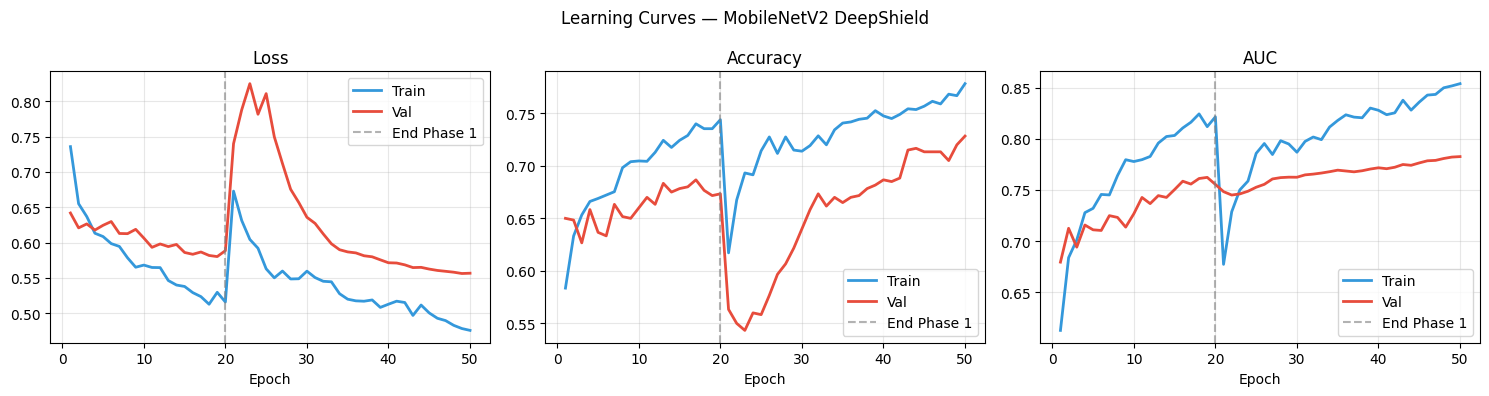

 Courbes sauvegardées.


In [8]:
merged = {k: history1.history[k] + history2.history[k] for k in history1.history}
ep     = range(1, len(merged['loss']) + 1)
p1_end = len(history1.history['loss'])

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Learning Curves — MobileNetV2 DeepShield', fontsize=12)

for ax, m, title in zip(axes, ['loss','accuracy','auc'], ['Loss','Accuracy','AUC']):
    ax.plot(ep, merged[m],            label='Train', color='#3498db', lw=2)
    ax.plot(ep, merged[f'val_{m}'],   label='Val',   color='#e74c3c', lw=2)
    ax.axvline(p1_end, color='gray', ls='--', alpha=0.6, label='End Phase 1')
    ax.set_title(title); ax.set_xlabel('Epoch')
    ax.legend(); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'learning_curves.png'), dpi=120)
plt.show()
print(' Courbes sauvegardées.')

---
## Évaluation sur le Test Set

In [9]:
best_model = keras.models.load_model(BEST_MODEL)
print(f' Meilleur modèle chargé : {BEST_MODEL}\n')

results      = best_model.evaluate(X_test, y_test, batch_size=16, verbose=0)
y_pred_proba = best_model.predict(X_test, batch_size=16, verbose=0).flatten()
y_pred       = (y_pred_proba >= 0.5).astype(int)
auc_score    = roc_auc_score(y_test, y_pred_proba)

print('='*45)
print('RÉSULTATS FINAUX — Test Set')
print('='*45)
for name, val in zip(best_model.metrics_names, results):
    print(f'  {name:12s} : {val:.4f}')
print(f'  {"auc_sklearn":12s} : {auc_score:.4f}')
print('='*45)
print(f'\nDistribution des scores :')
print(f'  min={y_pred_proba.min():.4f}  max={y_pred_proba.max():.4f}  '
      f'mean={y_pred_proba.mean():.4f}  std={y_pred_proba.std():.4f}')

if y_pred_proba.std() > 0.10:
    print('\n Le modèle discrimine bien les deux classes !')
else:
    print('\n std < 0.10 — modèle pas assez convergé, augmente EPOCHS_HEAD')

 Meilleur modèle chargé : ..\models\deepshield_best.keras

RÉSULTATS FINAUX — Test Set
  loss         : 0.6106
  compile_metrics : 0.6983
  auc_sklearn  : 0.7549

Distribution des scores :
  min=0.0019  max=0.9861  mean=0.5056  std=0.2599

 Le modèle discrimine bien les deux classes !


---
##  Matrice de Confusion

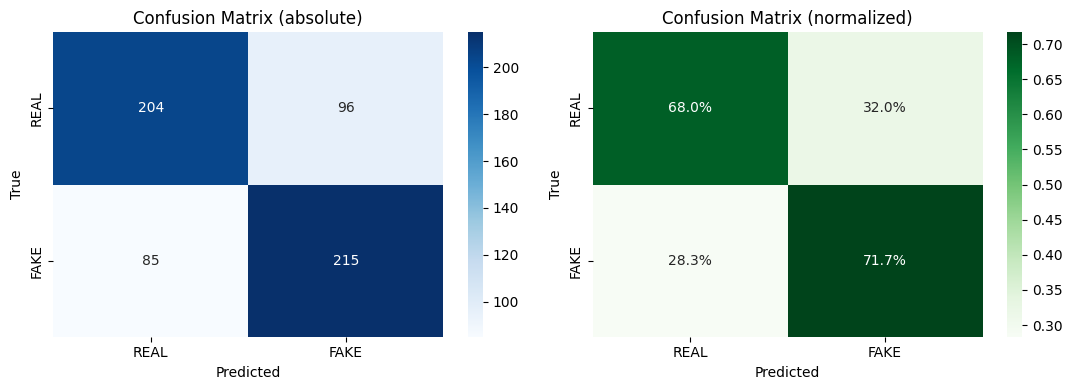

              precision    recall  f1-score   support

        REAL       0.71      0.68      0.69       300
        FAKE       0.69      0.72      0.70       300

    accuracy                           0.70       600
   macro avg       0.70      0.70      0.70       600
weighted avg       0.70      0.70      0.70       600



In [10]:
cm = confusion_matrix(y_test, y_pred)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['REAL','FAKE'], yticklabels=['REAL','FAKE'], ax=axes[0])
axes[0].set_title('Confusion Matrix (absolute)')
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('True')

cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_norm, annot=True, fmt='.1%', cmap='Greens',
            xticklabels=['REAL','FAKE'], yticklabels=['REAL','FAKE'], ax=axes[1])
axes[1].set_title('Confusion Matrix (normalized)')
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('True')

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'confusion_matrix.png'), dpi=120)
plt.show()
print(classification_report(y_test, y_pred, target_names=['REAL','FAKE']))

---
##  Courbe ROC

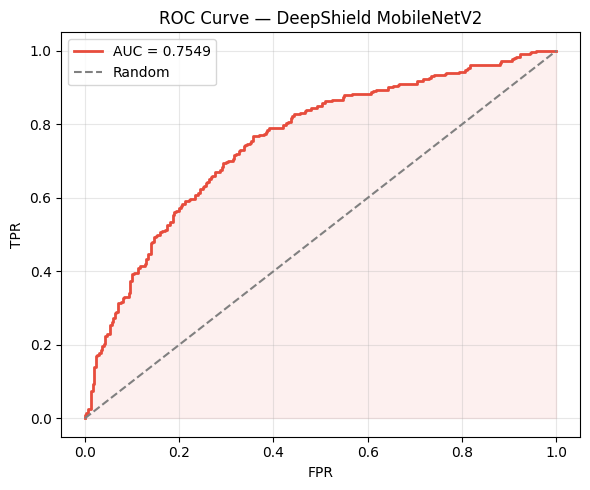

 ROC curve saved.


In [11]:
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='#e74c3c', lw=2, label=f'AUC = {auc_score:.4f}')
plt.plot([0,1],[0,1], 'gray', ls='--', label='Random')
plt.fill_between(fpr, tpr, alpha=0.08, color='#e74c3c')
plt.xlabel('FPR'); plt.ylabel('TPR')
plt.title('ROC Curve — DeepShield MobileNetV2')
plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'roc_curve.png'), dpi=120)
plt.show()
print(' ROC curve saved.')

---
##  Sauvegarde Finale

In [ ]:
final_path = os.path.join(MODELS_DIR, 'deepshield_final.keras')
best_model.save(final_path)
print(f' Modèle sauvegardé : {final_path}')

metrics_dict = dict(zip(best_model.metrics_names, results))
metrics_dict['auc_sklearn'] = auc_score
df = pd.DataFrame([metrics_dict])
csv_path = os.path.join(RESULTS_DIR, 'metrics_summary.csv')
df.to_csv(csv_path, index=False)
print(f' Métriques sauvegardées : {csv_path}')
print('\n' + df.to_string(index=False))
print('\n' + '='*50)

print('    Prochain : 03_gradcam.ipynb')
print('='*50)

 Modèle sauvegardé : ..\models\deepshield_final.keras
 Métriques sauvegardées : ..\results\metrics_summary.csv

    loss  compile_metrics  auc_sklearn
0.610587         0.698333     0.754856

 Notebook 2 terminé !
    Prochain : 03_gradcam.ipynb


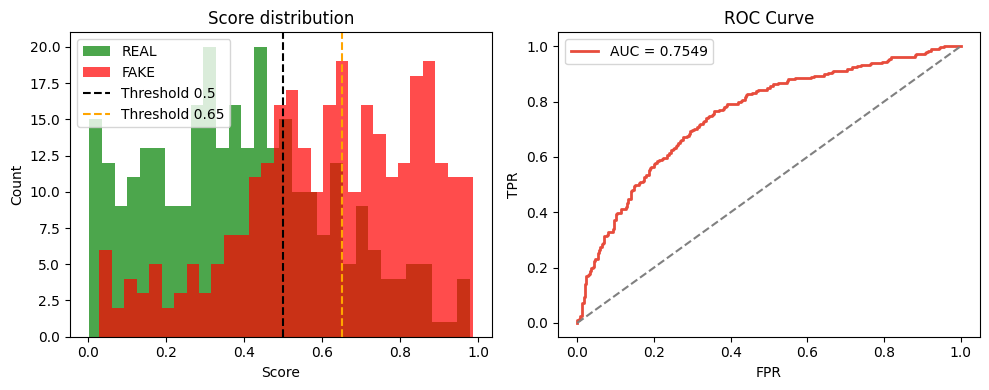

AUC         : 0.7549
REAL scores : mean=0.393  std=0.235  max=0.978
FAKE scores : mean=0.619  std=0.233  min=0.028

Zone ambiguë (0.4-0.6) : 162 images sur 600


In [13]:
import numpy as np
from tensorflow import keras
import matplotlib.pyplot as plt

# Charger
model  = keras.models.load_model(r'..\models\deepshield_best.keras')
X_test = np.load(r'..\data\processed\X_test.npy')
y_test = np.load(r'..\data\processed\y_test.npy')

# Prédictions complètes
preds = model.predict(X_test, batch_size=16, verbose=0).flatten()

# Distribution des scores
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.hist(preds[y_test==0], bins=30, alpha=0.7, color='green', label='REAL')
plt.hist(preds[y_test==1], bins=30, alpha=0.7, color='red',   label='FAKE')
plt.axvline(0.5, color='black', ls='--', label='Threshold 0.5')
plt.axvline(0.65, color='orange', ls='--', label='Threshold 0.65')
plt.xlabel('Score'); plt.ylabel('Count')
plt.title('Score distribution'); plt.legend()

plt.subplot(1, 2, 2)
from sklearn.metrics import roc_curve, roc_auc_score
fpr, tpr, _ = roc_curve(y_test, preds)
auc = roc_auc_score(y_test, preds)
plt.plot(fpr, tpr, color='#e74c3c', lw=2, label=f'AUC = {auc:.4f}')
plt.plot([0,1],[0,1],'gray',ls='--')
plt.xlabel('FPR'); plt.ylabel('TPR')
plt.title('ROC Curve'); plt.legend()

plt.tight_layout()
plt.show()

# Stats
real_scores = preds[y_test==0]
fake_scores = preds[y_test==1]
print(f'AUC         : {auc:.4f}')
print(f'REAL scores : mean={real_scores.mean():.3f}  std={real_scores.std():.3f}  max={real_scores.max():.3f}')
print(f'FAKE scores : mean={fake_scores.mean():.3f}  std={fake_scores.std():.3f}  min={fake_scores.min():.3f}')
print(f'\nZone ambiguë (0.4-0.6) : {sum((preds>0.4)&(preds<0.6))} images sur {len(preds)}')